# Atelier Préparation de Données Tabulaires

## Contexte

Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de fonctionnement et l'état du système de climatisation.

Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning capable de prédire la consommation énergétique ou de détecter les situations anormales.

Cependant, les données brutes présentent volontairement différents problèmes : valeurs manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables.

L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt pour le Machine Learning.

# Partie 1 – Explorer les données

In [1]:
# Question 1 : Charger les données CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/smart_building_raw.csv")

In [2]:
# Question 2 : Afficher les premières lignes du dataset
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


In [3]:
# Question 3 : Afficher les dernières lignes du dataset
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


In [4]:
# Question 4 : Nombre d'observations du dataset
obs = df.shape[0]
print(f"Nombre d'observations : {obs}")

Nombre d'observations : 507


In [5]:
# Question 5 : Nombre de variables du dataset
nbre_variables = df.shape[1]
print(f"Nombre de variables : {nbre_variables}")

Nombre de variables : 14


In [6]:
# Question 6 : Identifier les variables numériques
variable_numerique = df.select_dtypes(include=[np.number]).columns
print(f"Variables numériques : {variable_numerique}")

Variables numériques : Index(['id_mesure', 'temperature', 'humidite', 'co2', 'occupation',
       'consommation_kwh'],
      dtype='object')


In [7]:
# Question 7 : Identifier les variables catégorielles
variable_categorique = df.select_dtypes(include=['object']).columns
print(f"Variables catégorielles : {variable_categorique}")

Variables catégorielles : Index(['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation',
       'etat_systeme', 'jour_semaine', 'alerte'],
      dtype='object')


In [8]:
# Question 8 : Identifier les colonnes de type date
df.dtypes

id_mesure               int64
date                   object
batiment               object
type_batiment          object
zone                   object
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation     object
etat_systeme           object
jour_semaine           object
alerte                 object
dtype: object

In [9]:
# Question 9 : Identifier les identifiants
print("Nombre de lignes :", df.shape[0])
print("Valeurs uniques id_mesure :", df['id_mesure'].nunique())
print("Valeurs uniques batiment :", df['batiment'].nunique())

# id_mesure est l'identifiant du dataset, bien qu'il contienne quelques doublons
# (507 lignes vs 500 valeurs uniques) 

Nombre de lignes : 507
Valeurs uniques id_mesure : 500
Valeurs uniques batiment : 8


In [10]:
# Question 10 : Statistiques descriptives (moyenne, médiane, min, max, écart-type, quartiles)
df.describe()

,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


In [11]:
# Question 11 : Variables potentiellement problématiques

**Variables potentiellement problématiques identifiées :**

- **temperature** : valeurs manquantes (12) + valeurs aberrantes (min = -30°C, max = 96°C, physiquement impossibles pour un bâtiment)
- **humidite** : valeurs manquantes (11) + valeurs incohérentes (min = -12, max = 160 ; une humidité relative doit être comprise entre 0 et 100%)
- **co2** : valeurs manquantes (7) + valeur aberrante extrême (max = 6000, très au-dessus de la moyenne de ~844 et du 75e percentile de 952)
- **occupation** : valeurs manquantes (6) + valeur négative impossible (min = -20 ; un nombre de personnes ne peut pas être négatif)
- **consommation_kwh** : valeurs manquantes (5) + valeur négative impossible (min = -100)
- **id_mesure** : contient des doublons (500 valeurs uniques pour 507 lignes) alors qu'il devrait être unique

In [12]:
# Question 12.a : Rechercher des valeurs telles que humidité < 0
df[df['humidite'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


In [13]:
# Question 12.b : Rechercher des valeurs telles que humidité > 100
df[df['humidite'] > 100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


In [14]:
# Question 12.c : Rechercher des valeurs de température extrêmement élevée
df[df['temperature'] > 50]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05 00:00:00,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15 00:00:00,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16 00:00:00,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
499,1021,2025-01-06 00:00:00,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


In [15]:
# Question 12.d : Rechercher des valeurs d'occupation négative
df[df['occupation'] < 0]
# Aucune valeur négative trouvée pour le CO2

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
22,1031,2025-01-08 12:00:00,B2,École,D,26.1,57.6,648.0,-5.0,170.0,Eco,Normal,Mercredi,Non
376,1231,2025-02-27 12:00:00,B7,Bureau,D,19.0,35.3,680.0,-8.0,167.9,Eco,Alerte,Jeudi,Non
430,1081,2025-01-21 00:00:00,B1,Bureau,B,23.5,44.1,541.0,-12.0,248.7,Boost,Normal,Mardi,Non
487,1131,2025-02-02 12:00:00,B1,entrepot,A,26.3,70.6,1519.0,-2.0,173.4,Normal,Panne,Dimanche,Oui
494,1331,2025-03-24 12:00:00,B5,Centre commercial,B,22.7,54.6,979.0,-20.0,178.6,Normal,Alerte,Lundi,Oui


In [16]:
# Question 12.e : Rechercher des valeurs de consommation négative
df[df['consommation_kwh'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


In [17]:
# Question 12.f : Transformer les valeurs manifestement erronées en valeurs manquantes
df.loc[df['humidite'] < 0, 'humidite'] = np.nan
df.loc[df['humidite'] > 100, 'humidite'] = np.nan
df.loc[df['temperature'] > 50, 'temperature'] = np.nan
df.loc[df['consommation_kwh'] < 0, 'consommation_kwh'] = np.nan
df.loc[df['occupation'] < 0, 'occupation'] = np.nan

# Vérification
df[['temperature', 'humidite', 'co2', 'consommation_kwh', 'occupation']].describe()

,temperature,humidite,co2,consommation_kwh,occupation
count,491.000000,486.000000,500.000000,498.000000,496.000000
mean,23.634623,57.213169,844.150000,170.798795,45.397177
std,4.613895,12.331736,582.181386,49.637307,24.460678
min,-30.000000,21.500000,89.000000,26.400000,0.000000
25%,21.600000,49.350000,623.750000,137.675000,28.000000
50%,24.000000,57.400000,787.500000,170.100000,46.000000
75%,25.900000,65.300000,952.000000,204.150000,61.000000
max,34.200000,90.700000,6000.000000,336.200000,116.000000


In [18]:
# Question 12.g : Rechercher des valeurs telles que catégories mal orthographiées
for col in df.select_dtypes(include=['object']).columns:
    if col != 'date':
        print(col, ":", df[col].unique())
        print()

batiment : ['B8' 'B7' 'B5' 'B6' 'B3' 'B4' 'B2' 'B1']

type_batiment : ['Entrepôt' 'Bureau' 'Centre commercial' 'Université' 'Hôpital' 'École'
 'ÉCOLE' 'ecole' 'BUREAU' nan 'Bureu' 'bureau' ' UNIVERSITÉ' 'hôpital '
 'centre commercial' ' Bureau ' 'entrepot']

zone : ['A' 'D' 'B' 'C']

mode_climatisation : ['Eco' 'Normal' 'Boost' nan 'normal' 'BOOST' 'normale' 'Normal ']

etat_systeme : ['Normal' 'Alerte' 'Panne']

jour_semaine : ['Jeudi' 'Lundi' 'Dimanche' 'Vendredi' 'Mercredi' 'Mardi' 'Samedi' nan]

alerte : ['Non' 'Oui']



**Anomalies détectées dans les variables catégorielles :**

- **type_batiment** : variantes de casse (École/ÉCOLE/ecole, Bureau/BUREAU/bureau, centre commercial, entrepot), faute de frappe (Bureu), espaces superflus ( UNIVERSITÉ, hôpital , Bureau )
- **mode_climatisation** : variantes de casse (Normal/normal/normale, Boost/BOOST), espace superflu (Normal )
- **jour_semaine** : valeurs manquantes uniquement, pas d'incohérence de format

In [19]:
# Question 12.h : Normaliser les catégories textuelles (espaces + casse)
for col in ['type_batiment', 'mode_climatisation']:
    df[col] = df[col].str.strip().str.capitalize()

# Vérification
print(df['type_batiment'].unique())
print(df['mode_climatisation'].unique())

['Entrepôt' 'Bureau' 'Centre commercial' 'Université' 'Hôpital' 'École'
 'Ecole' nan 'Bureu' 'Entrepot']
['Eco' 'Normal' 'Boost' nan 'Normale']


In [20]:
# Question 12.h (suite) : Correction des cas résiduels (accents, fautes de frappe)
df['type_batiment'] = df['type_batiment'].replace({
    'Ecole': 'École',
    'Bureu': 'Bureau',
    'Entrepot': 'Entrepôt'
})

df['mode_climatisation'] = df['mode_climatisation'].replace({
    'Normale': 'Normal'
})

# Vérification finale
print(df['type_batiment'].unique())
print(df['mode_climatisation'].unique())

['Entrepôt' 'Bureau' 'Centre commercial' 'Université' 'Hôpital' 'École'
 nan]
['Eco' 'Normal' 'Boost' nan]


In [21]:
# Question 13.a : Nombre et pourcentage de valeurs manquantes par colonne
missing_count = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'nombre_manquants': missing_count,
    'pourcentage_manquants': missing_pct.round(2)
})
missing_summary[missing_summary['nombre_manquants'] > 0].sort_values('nombre_manquants', ascending=False)

,nombre_manquants,pourcentage_manquants
humidite,21,4.14
temperature,16,3.16
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


In [22]:
# Question 13.b : Variable avec le plus de valeurs manquantes

La variable avec le plus de valeurs manquantes est **humidite**, avec 21 valeurs manquantes (4.14% du dataset).

In [23]:
# Question 13.c : Stratégie pour les valeurs manquantes
print("Lignes actuelles :", df.shape[0])
print("Lignes restantes après dropna() :", df.dropna().shape[0])
print("Lignes qui seraient perdues :", df.shape[0] - df.dropna().shape[0])
print("Pourcentage perdu :", round((df.shape[0] - df.dropna().shape[0]) / df.shape[0] * 100, 2), "%")

Lignes actuelles : 507
Lignes restantes après dropna() : 436
Lignes qui seraient perdues : 71
Pourcentage perdu : 14.0 %


**Stratégie retenue : imputation, pas suppression**

Bien que chaque colonne prise isolément ait un faible pourcentage de valeurs manquantes (entre 0.79% et 4.14%), une suppression des lignes concernées (`dropna()`) ferait perdre **13.02% du dataset** (66 lignes sur 507), car les valeurs manquantes sont dispersées sur des lignes différentes selon la colonne.

On privilégie donc l'**imputation**, différenciée selon le type de variable :
- Variables numériques → imputation par la moyenne ou la médiane (selon la distribution)
- Variables catégorielles → imputation par le mode (valeur la plus fréquente)

Cette approche conserve un maximum d'information exploitable pour le futur modèle de Machine Learning.

**Question 13.d : Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?**

Non, ce n'est pas recommandé ici. Comme montré en Q13.c, cela ferait perdre 13.02% du dataset (66 lignes sur 507), alors que chaque colonne individuellement n'a qu'un faible taux de manquants. Ces lignes contiennent souvent des informations valides sur les autres variables, qu'on perdrait inutilement. L'imputation est préférable pour conserver un maximum de données exploitables.

**Question 13.e : Dans quels cas utiliser la moyenne ?**

La moyenne est adaptée pour imputer une variable numérique lorsque :
- sa distribution est approximativement **symétrique** (pas ou peu de valeurs extrêmes qui la tirent vers le haut ou le bas)
- elle ne contient pas (ou plus, après nettoyage) de valeurs aberrantes marquées, car la moyenne est très sensible aux extrêmes

**Question 13.f : Quand préférer la médiane ?**

La médiane est préférable à la moyenne lorsque :
- la distribution est **asymétrique** (skewed), c'est-à-dire qu'elle a une longue "queue" d'un côté
- la variable contient des **valeurs aberrantes** (outliers) qu'on n'a pas pu totalement éliminer, car la médiane, contrairement à la moyenne, n'est pas influencée par les valeurs extrêmes (elle représente juste la valeur du milieu, une fois les données triées)

C'est généralement le choix le plus robuste par défaut pour des données de capteurs comme les nôtres (temperature, humidite, co2, consommation_kwh), qui ont déjà montré des valeurs aberrantes en Q10-Q12 — même après nettoyage, la médiane reste un choix plus prudent que la moyenne.

**Question 13.g : Comment traiter une variable catégorielle ?**

Pour une variable catégorielle (texte), on ne peut pas utiliser la moyenne ou la médiane, qui n'ont de sens que pour des variables numériques. On utilise à la place le **mode** : la valeur la plus fréquente de la colonne, qui remplace les valeurs manquantes.

Dans notre dataset, cette stratégie s'applique aux colonnes `type_batiment`, `mode_climatisation` et `jour_semaine`, qui contiennent chacune quelques valeurs manquantes (voir Q13.a). C'est d'ailleurs l'approche prévue dans le pipeline de preprocessing (Partie 6, bloc "Imputation mode" pour les variables catégorielles).

In [24]:
# Question 14.a : Identifier les doublons
df.duplicated().sum()

np.int64(7)

In [25]:
# Question 14.b : Afficher les doublons
df[df.duplicated(subset='id_mesure', keep=False)].sort_values('id_mesure')

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


In [26]:
# Question 14.c : Vérifier si les doublons sont réellement identiques (toutes colonnes)
# keep=False : marque comme doublon TOUTES les occurrences d'une ligne répétée
# (pas seulement la 2e copie), pour bien vérifier chaque paire dans son ensemble

df[df.duplicated(subset='id_mesure', keep=False)].duplicated(keep=False).all()

np.True_

**Question 14.c : Sont-ils réellement identiques ?**

Oui, les 7 paires de lignes dupliquées (sur `id_mesure`) sont des doublons parfaits — identiques sur toutes les colonnes (date, batiment, temperature, humidite, etc.), pas seulement sur l'identifiant.

In [27]:
# Question 14.d : Supprimer les doublons réellement identifiés
df = df.drop_duplicates()

In [28]:
# Question 14.e : Vérifier la suppression des doublons
print("Nombre de lignes après suppression :", df.shape[0])
print("Doublons restants :", df.duplicated().sum())

Nombre de lignes après suppression : 500
Doublons restants : 0


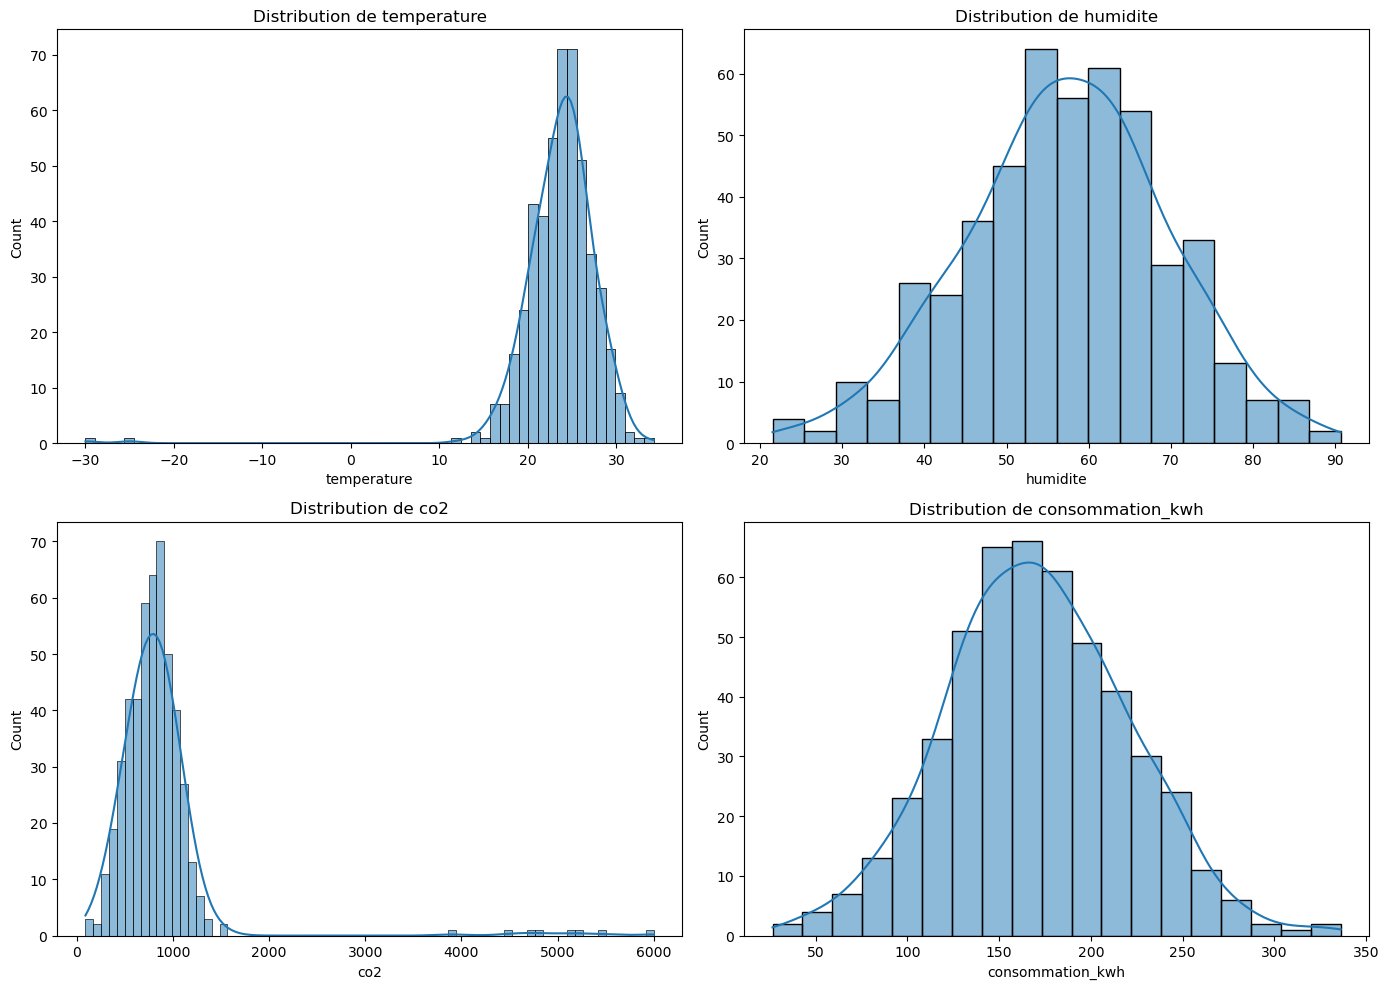

In [29]:
# Question 15 : Visualiser les distributions (température, humidité, CO2, consommation)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
variables = ['temperature', 'humidite', 'co2', 'consommation_kwh']

for ax, var in zip(axes.flatten(), variables):
    sns.histplot(df[var], kde=True, ax=ax)
    ax.set_title(f'Distribution de {var}')

plt.tight_layout()
plt.show()

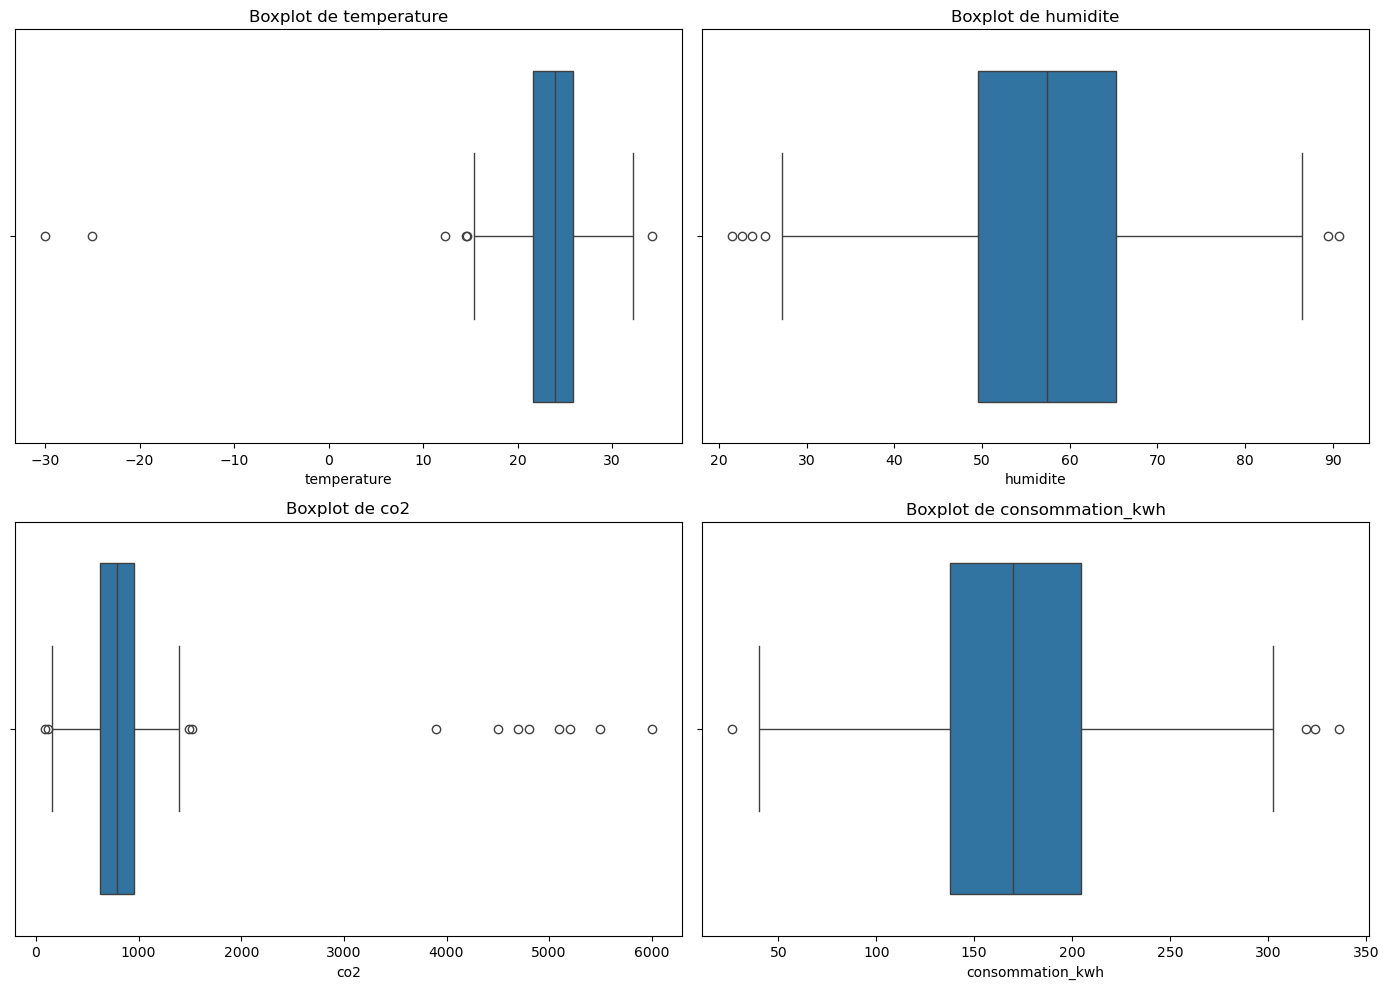

In [30]:
# Boxplots pour repérer dispersion et valeurs extrêmes/aberrantes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(x=df[var], ax=ax)
    ax.set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

**Question 15.a : Les distributions sont-elles symétriques ou non ?**

- **temperature** : distribution globalement symétrique en forme de cloche, centrée autour de 22-25°C — sauf pour un petit groupe de valeurs isolées très négatives (autour de -30, -25), qui sont clairement hors de la distribution principale.
- **humidite** : distribution globalement symétrique en forme de cloche, centrée autour de 55-65.
- **co2** : distribution **fortement asymétrique à droite**  — la majorité des valeurs se concentre entre 0 et 1500, avec une longue traîne de valeurs isolées s'étirant jusqu'à 6000.
- **consommation_kwh** : distribution globalement symétrique en forme de cloche, centrée autour de 150-200.

**Question 15.b : La dispersion**

- **temperature** : dispersion faible — la majorité des valeurs sont resserrées entre 20 et 30°C (boîte étroite sur le boxplot), écart-type d'environ 4.6 (hors valeurs aberrantes déjà nettoyées en Q12).
- **humidite** : dispersion modérée — les valeurs s'étalent de 20 à 90 environ, boîte plus large que temperature.
- **co2** : dispersion très forte en apparence (écart-type ~582 vu en Q10), mais ceci est trompeur — c'est surtout dû à la traîne de valeurs extrêmes (4000-6000). Le "corps" principal de la distribution (0-1500) est en réalité assez concentré.
- **consommation_kwh** : dispersion modérée à large — les valeurs s'étalent globalement entre 50 et 300, boîte assez large sur le boxplot, cohérent avec un écart-type d'environ 50.

**Question 15.c : Les valeurs extrêmes**

Visibles sur les boxplots sous forme de points isolés au-delà des moustaches :

- **temperature** : deux points isolés très à gauche, autour de -30 et -25°C.
- **humidite** : quelques points isolés à gauche (autour de 20-25) et deux points isolés à droite (autour de 87-90).
- **co2** : de nombreux points isolés à droite, échelonnés entre environ 4000 et 6000, bien au-delà de la moustache supérieure (~1400).
- **consommation_kwh** : quelques points isolés à droite (autour de 300-335) et un point isolé à gauche (proche de 25-30).

**Question 15.d : Les valeurs potentiellement aberrantes**

Parmi les valeurs extrêmes identifiées en 15.c, certaines sont physiquement impossibles et donc clairement aberrantes (erreurs de capteur), pas de simples valeurs rares mais plausibles :

- **temperature** : les valeurs autour de -30°C et -25°C sont aberrantes — une température intérieure de bâtiment ne descend pas à ce niveau.
- **humidite** : les valeurs autour de 20-25 restent physiquement possibles (air très sec), donc pas nécessairement aberrantes ; celles autour de 87-90 sont également plausibles (air très humide). Aucune valeur clairement aberrante restante ici après le nettoyage de la Q12.
- **co2** : les valeurs entre 4000 et 6000 sont très suspectes — un taux de CO₂ aussi élevé en continu indiquerait une situation dangereuse et rare, largement déconnectée du reste des observations (qui culminent vers 1400-1500). Fortement aberrantes.
- **consommation_kwh** : les valeurs autour de 300-335 restent dans une plage plausible pour un pic de consommation ; pas d'indice fort d'aberration ici.

En résumé, les vraies valeurs aberrantes restantes concernent principalement **temperature** (valeurs négatives extrêmes) et **co2** (valeurs extrêmement élevées) — elles seront traitées à la question 16.

**Question 16 : Stratégie pour les valeurs aberrantes**

Pour `temperature` (valeurs négatives extrêmes, ex: -30°C) et `co2` (valeurs extrêmement élevées, ex: 4000-6000), ces valeurs sont physiquement impossibles ou fortement suspectes — probablement des erreurs de capteur, pas de vraies mesures extrêmes.

Par cohérence avec la stratégie déjà appliquée en Q12.f, on les transforme en valeurs manquantes (NaN), puisqu'on ne peut pas retrouver leur vraie valeur. Elles seront ensuite traitées par imputation (médiane, comme justifié en Q13.f pour les distributions avec outliers), plutôt que par un plafonnement arbitraire.

In [31]:
# Application : transformation des valeurs aberrantes restantes en NaN
df.loc[df['temperature'] < -10, 'temperature'] = np.nan
df.loc[df['co2'] > 2000, 'co2'] = np.nan

# Vérification
df[['temperature', 'co2']].describe()

,temperature,co2
count,482.000000,485.000000
mean,23.843776,777.723711
std,3.266553,240.378468
min,12.300000,89.000000
25%,21.600000,621.000000
50%,24.000000,783.000000
75%,25.900000,942.000000
max,34.200000,1519.000000


In [32]:
# Question 17.a : Fréquence des bâtiments
df['batiment'].value_counts()

batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64

In [33]:
# Question 17.b : Fréquence des types de bâtiments
df['type_batiment'].value_counts()

type_batiment
Bureau               211
Centre commercial     65
École                 60
Hôpital               58
Entrepôt              53
Université            49
Name: count, dtype: int64

In [34]:
# Question 17.c : Fréquence des modes de climatisation
df['mode_climatisation'].value_counts()

mode_climatisation
Normal    268
Eco       130
Boost      97
Name: count, dtype: int64

In [35]:
# Question 17.d : Fréquence des états du système
df['etat_systeme'].value_counts()

etat_systeme
Normal    436
Alerte     52
Panne      12
Name: count, dtype: int64

In [36]:
# Question 17.e : Fréquence des classes alerte
df['alerte'].value_counts()

alerte
Non    356
Oui    144
Name: count, dtype: int64

In [37]:
# Question 18 : Déséquilibre des classes sur la variable alerte
df['alerte'].value_counts(normalize=True) * 100

#normalize=True donne les proportions au lieu des comptes bruts, ce qui est utile pour évaluer le déséquilibre des classes.

alerte
Non    71.2
Oui    28.8
Name: proportion, dtype: float64

**Question 18 : Déséquilibre des classes sur la variable "alerte"**

Oui, il y a un déséquilibre des classes : 71.2% des observations sont "Non" contre 28.8% "Oui" (ratio ~2.5:1).

Ce déséquilibre est **modéré**, pas extrême (on serait dans un cas sévère avec un ratio de 10:1 ou plus, comme dans la détection de fraude par exemple). Il reste néanmoins à garder à l'esprit pour la suite :
- Lors du découpage train/test (Partie 3), il faudra utiliser une **stratification** (`stratify=y`) pour conserver ces mêmes proportions dans les deux ensembles.
- Lors de l'évaluation d'un futur modèle, l'accuracy seule serait trompeuse — il faudra privilégier des métriques comme le F1-score, la precision/recall, ou l'AUC-ROC.

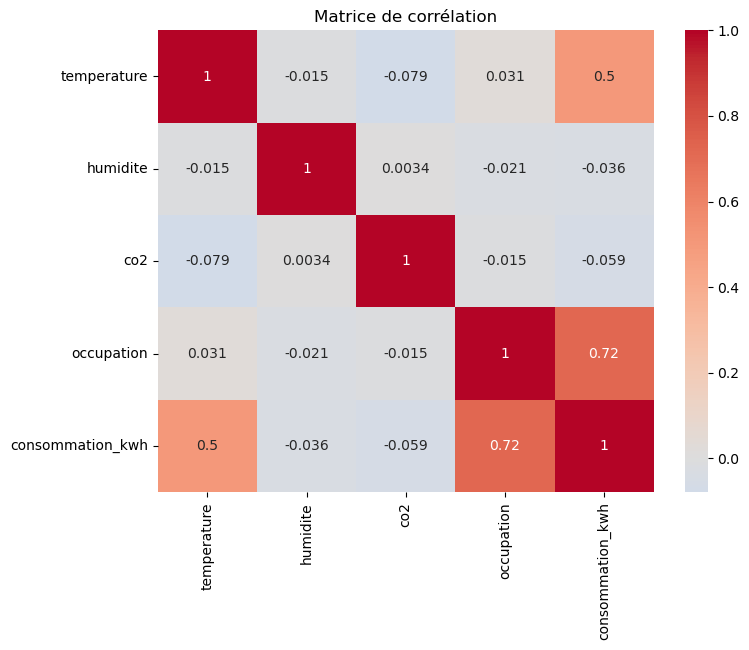

In [38]:
# Question 19.a : Matrice de corrélation des variables numériques
numeric_cols = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

**Question 19.b : Interprétation de la matrice de corrélation**

- **Corrélations positives notables** :
  - `occupation` et `consommation_kwh` : 0.69 → corrélation positive modérée à forte. Logique : plus il y a de personnes présentes, plus la consommation énergétique augmente.
  - `temperature` et `consommation_kwh` : 0.5 → corrélation positive modérée. Cohérent : une température plus élevée entraîne davantage de climatisation, donc plus de consommation.

- **Corrélations négatives** : aucune n'est notable — toutes les valeurs négatives de la matrice sont très proches de 0 (entre -0.015 et -0.079), donc négligeables.

- **Variables faiblement corrélées entre elles** (proches de 0, quasi indépendantes) :
  - `humidite` avec toutes les autres variables (valeurs entre -0.036 et 0.0034)
  - `co2` avec toutes les autres variables (valeurs entre -0.079 et 0.0034)
  - `temperature` et `occupation` (0.034)
  - `temperature` et `humidite` (-0.015)

En résumé, les deux relations les plus exploitables pour un futur modèle sont `occupation` → `consommation_kwh` et `temperature` → `consommation_kwh`. Les autres variables numériques apportent une information globalement indépendante les unes des autres, ce qui est plutôt positif (peu de redondance, pas de risque fort de multicolinéarité).

# Partie 2 – Séparation X / y

In [39]:
# Question 1 : Définir la cible y
y = df['alerte']

In [40]:
# Question 2 : Variables explicatives X pertinentes
X = df.drop(columns=['alerte', 'id_mesure', 'date'])
X.columns

Index(['batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2',
       'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme',
       'jour_semaine'],
      dtype='object')

**Question 2 : Justification des exclusions**

- **alerte** : c'est la variable cible (`y`), elle ne doit jamais figurer dans `X` — sinon le modèle "trichera" en utilisant directement la réponse qu'il est censé prédire (fuite de données).
- **id_mesure** : simple identifiant unique de chaque ligne, sans lien logique avec le phénomène à prédire (vu en Q9) — l'inclure risquerait même de faire apprendre au modèle un artefact d'ordre plutôt qu'un vrai signal.
- **date** : sous sa forme brute (texte/datetime), elle n'est pas directement exploitable par un modèle ; l'information temporelle pertinente est déjà partiellement capturée par `jour_semaine`, qui est plus directement interprétable comme variable catégorielle.

In [41]:
# Question 3 : Cinq premières lignes de X et y
print("Premières lignes de X :")
print(X.head())

print("\nPremières lignes de y :")
print(y.head())

Premières lignes de X :
  batiment      type_batiment zone  temperature  humidite     co2  occupation  \
0       B8           Entrepôt    A         23.0      40.0   851.0        26.0   
1       B7             Bureau    D         28.0      69.0   538.0         0.0   
2       B5  Centre commercial    B         19.5      52.3  1198.0        64.0   
3       B6         Université    D         20.0      58.4  1014.0        30.0   
4       B7             Bureau    D         26.8      70.5   628.0        42.0   

   consommation_kwh mode_climatisation etat_systeme jour_semaine  
0             138.4                Eco       Normal        Jeudi  
1             170.2                Eco       Normal        Lundi  
2             149.8             Normal       Normal     Dimanche  
3             141.6             Normal       Normal     Dimanche  
4             228.3             Normal       Normal        Jeudi  

Premières lignes de y :
0    Non
1    Non
2    Oui
3    Non
4    Non
Name: alerte, dty

# Partie 3 – Découpage Train/Test

In [42]:
# Question 1 : Découpage train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)

Taille X_train : (400, 11)
Taille X_test : (100, 11)


In [43]:
# Vérification de la stratification
print("Proportions dans y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nProportions dans y_test :")
print(y_test.value_counts(normalize=True) * 100)

Proportions dans y_train :
alerte
Non    71.25
Oui    28.75
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
Non    71.0
Oui    29.0
Name: proportion, dtype: float64


# Partie 4 – Encodage des variables catégorielles

In [44]:
# Variable 1 — batiment
print(X['batiment'].nunique(), X['batiment'].unique())

8 ['B8' 'B7' 'B5' 'B6' 'B3' 'B4' 'B2' 'B1']


**Encodage de `batiment` : One-Hot Encoding**

`batiment` est une variable **nominale** (pas d'ordre logique entre B1, B2... B8). Le One-Hot Encoding est adapté : il crée une colonne binaire par catégorie, évitant qu'un modèle interprète à tort une relation d'ordre (ce que ferait un Label Encoding en assignant 0, 1, 2... aux bâtiments). Avec seulement 8 catégories, l'augmentation du nombre de colonnes reste raisonnable.

In [45]:
# Variable 2 — type_batiment

# nunique() donne le nombre de valeurs distinctes, unique() donne la liste de ces valeurs


print(X['type_batiment'].nunique(), X['type_batiment'].unique())

6 ['Entrepôt' 'Bureau' 'Centre commercial' 'Université' 'Hôpital' 'École'
 nan]


**Encodage de `type_batiment` : One-Hot Encoding**

Comme `batiment`, c'est une variable **nominale** sans hiérarchie entre les catégories (un "Hôpital" n'est ni supérieur ni inférieur à un "Bureau"). One-Hot Encoding évite d'introduire une fausse relation d'ordre. 6 catégories → augmentation raisonnable du nombre de colonnes.

In [46]:
# Variable 3 — zone

print(X['zone'].nunique(), X['zone'].unique())

4 ['A' 'D' 'B' 'C']


**Encodage de `zone` : One-Hot Encoding**

Variable **nominale** — les lettres A, B, C, D désignent des zones distinctes dans un bâtiment, sans hiérarchie implicite. One-Hot Encoding adapté, avec seulement 4 catégories.

In [47]:
# Variable 4 — mode_climatisation

print(X['mode_climatisation'].nunique(), X['mode_climatisation'].unique())

3 ['Eco' 'Normal' 'Boost' nan]


**Encodage de `mode_climatisation` : Ordinal Encoding**

`mode_climatisation` possède un ordre naturel d'intensité : Eco < Normal < Boost. On utilise un encodage **ordinal**, via `OrdinalEncoder` de sklearn (avec l'ordre explicitement spécifié : `categories=[['Eco', 'Normal', 'Boost']]`), plutôt qu'un One-Hot Encoding. Cela préserve la relation d'ordre, une information potentiellement utile pour le modèle. On n'utilise pas `LabelEncoder`, réservé à l'encodage de la variable cible et qui n'assigne pas un ordre contrôlé.

Note : la colonne contient encore des valeurs manquantes (NaN) — elles devront être imputées (par le mode) avant l'application de l'encodage, conformément au pipeline prévu en Partie 6.

In [48]:
# Variable 5 — etat_systeme

print(X['etat_systeme'].nunique(), X['etat_systeme'].unique())

3 ['Normal' 'Alerte' 'Panne']


**Encodage de `etat_systeme` : Ordinal Encoding**

`etat_systeme` possède un ordre naturel de gravité croissante : Normal < Alerte < Panne. On utilise un encodage **ordinal** via `OrdinalEncoder` (avec l'ordre explicitement spécifié : `categories=[['Normal', 'Alerte', 'Panne']]`), afin de préserver cette hiérarchie de criticité, plutôt qu'un One-Hot Encoding qui traiterait ces états comme équivalents et indépendants.

In [49]:
# Variable 6 — jour_semaine

print(X['jour_semaine'].nunique(), X['jour_semaine'].unique())

7 ['Jeudi' 'Lundi' 'Dimanche' 'Vendredi' 'Mercredi' 'Mardi' 'Samedi' nan]


**Encodage de `jour_semaine` : One-Hot Encoding**

Bien que les jours de la semaine aient un ordre calendaire, cet ordre est **cyclique**, pas une échelle de grandeur (Dimanche n'est ni "supérieur" ni "inférieur" à Lundi en intensité). Un encodage ordinal introduirait une fausse relation numérique (ex: Dimanche=6 serait perçu comme "6 fois plus" que Lundi=0). On utilise donc un **One-Hot Encoding**, qui traite chaque jour comme une catégorie indépendante, plus fidèle à la nature réelle de la variable.

In [50]:
# Imputation des NaN catégoriels (mode calculé sur X_train uniquement)
cat_cols_to_impute = ['type_batiment', 'mode_climatisation', 'jour_semaine']

for col in cat_cols_to_impute:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Vérification
print(X_train[cat_cols_to_impute].isna().sum())
print(X_test[cat_cols_to_impute].isna().sum())

type_batiment         0
mode_climatisation    0
jour_semaine          0
dtype: int64
type_batiment         0
mode_climatisation    0
jour_semaine          0
dtype: int64


In [51]:
# Application : One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ['batiment', 'type_batiment', 'zone', 'jour_semaine']

encoder_oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder_oh.fit(X_train[onehot_cols])

X_train_oh = pd.DataFrame(
    encoder_oh.transform(X_train[onehot_cols]),
    columns=encoder_oh.get_feature_names_out(onehot_cols),
    index=X_train.index
)
X_test_oh = pd.DataFrame(
    encoder_oh.transform(X_test[onehot_cols]),
    columns=encoder_oh.get_feature_names_out(onehot_cols),
    index=X_test.index
)

X_train_oh.head()

,batiment_B1,batiment_B2,batiment_B3,batiment_B4,batiment_B5,batiment_B6,batiment_B7,batiment_B8,type_batiment_Bureau,type_batiment_Centre commercial,...,zone_B,zone_C,zone_D,jour_semaine_Dimanche,jour_semaine_Jeudi,jour_semaine_Lundi,jour_semaine_Mardi,jour_semaine_Mercredi,jour_semaine_Samedi,jour_semaine_Vendredi
265,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# Application : Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

encoder_ord = OrdinalEncoder(categories=[
    ['Eco', 'Normal', 'Boost'],
    ['Normal', 'Alerte', 'Panne']
])

ordinal_cols = ['mode_climatisation', 'etat_systeme']

encoder_ord.fit(X_train[ordinal_cols])

X_train_ord = pd.DataFrame(
    encoder_ord.transform(X_train[ordinal_cols]),
    columns=ordinal_cols,
    index=X_train.index
)
X_test_ord = pd.DataFrame(
    encoder_ord.transform(X_test[ordinal_cols]),
    columns=ordinal_cols,
    index=X_test.index
)

X_train_ord.head()

,mode_climatisation,etat_systeme
265,1.0,0.0
110,1.0,1.0
149,2.0,0.0
5,0.0,0.0
66,1.0,0.0


# Partie 5 – Mise à l'échelle

In [53]:
# Question 1 : Justifier la pertinence de la mise à l'échelle
X_train[['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']].describe()

,temperature,humidite,co2,occupation,consommation_kwh
count,386.000000,384.000000,388.000000,391.000000,392.000000
mean,23.800518,57.008073,776.126289,45.521739,170.468878
std,3.291658,12.096141,237.634427,24.762956,51.221598
min,12.300000,21.500000,89.000000,0.000000,26.400000
25%,21.700000,49.975000,622.500000,27.000000,135.600000
50%,23.900000,57.000000,779.000000,46.000000,169.200000
75%,25.900000,64.825000,942.000000,61.000000,205.150000
max,34.200000,89.500000,1519.000000,116.000000,336.200000


**Question 1 : Pertinence de la mise à l'échelle**

Les variables numériques évoluent sur des échelles très différentes : `temperature` varie entre 12.3 et 34.2 (amplitude ~22), tandis que `co2` varie entre 89 et 1519 (amplitude ~1430) — soit environ 65 fois plus large.

Cette différence d'échelle pose problème pour de nombreux algorithmes de Machine Learning sensibles aux distances ou aux gradients (régression logistique, SVM, k-NN, réseaux de neurones, PCA...) : sans mise à l'échelle, `co2` dominerait artificiellement le calcul simplement parce que ses valeurs sont numériquement plus grandes, même si elle n'est pas plus importante pour la prédiction. La mise à l'échelle place toutes les variables sur une base comparable, pour que le modèle apprenne à partir de leur véritable pouvoir prédictif, pas de leur magnitude brute.